In [24]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import nltk
from nltk.corpus import stopwords
from sklearn.metrics import ConfusionMatrixDisplay

In [25]:
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt_tab to /home/armaan/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /home/armaan/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [26]:
np.random.seed(0)

In [27]:
df = pd.read_excel('factoryReports.xlsx')
stop_words = set(stopwords.words('english'))
def preprocess_text(text):
    tokens = nltk.word_tokenize(text)
    tokens = [word.lower() for word in tokens if word.isalpha() and word.lower() not in stop_words]
    return ' '.join(tokens)


In [28]:
df['Description'] = df['Description'].apply(preprocess_text)
df['Category'] = df['Category'].apply(preprocess_text)

In [29]:
Tfidf_vectorizer = TfidfVectorizer()
X = Tfidf_vectorizer.fit_transform(df['Description'])
y = df['Category']
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

Accuracy: 0.8958333333333334


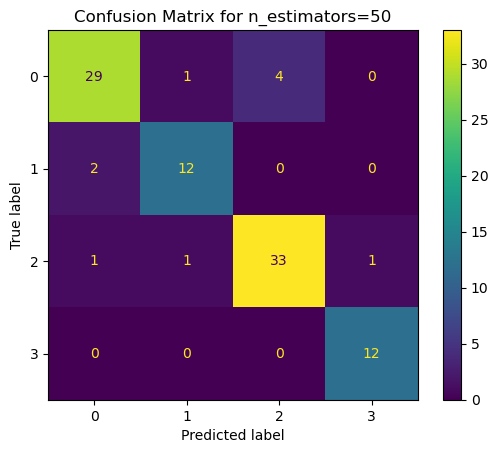

Accuracy: 0.9270833333333334


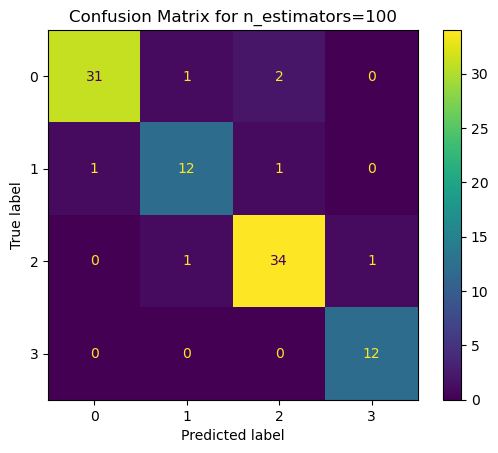

Accuracy: 0.90625


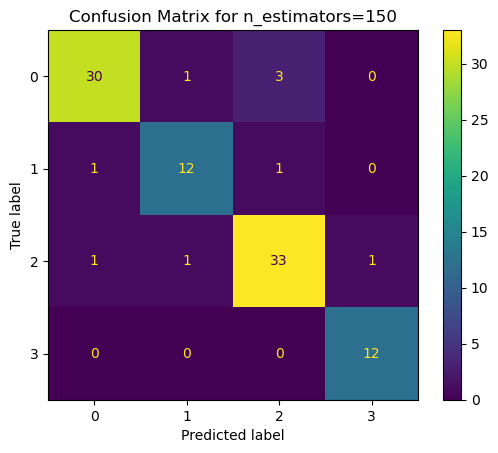

Accuracy: 0.90625


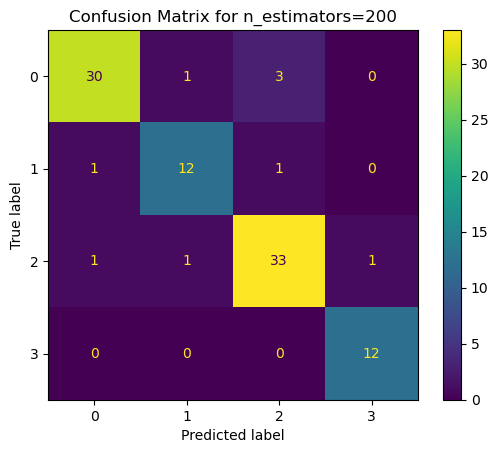

In [30]:
for i in [50, 100, 150, 200]:
    rf_classifier = RandomForestClassifier(n_estimators=i, random_state=42)
    rf_classifier.fit(x_train, y_train)
    y_pred = rf_classifier.predict(x_test)
    accuracy = accuracy_score(y_test, y_pred)
    conf_matrix = confusion_matrix(y_test, y_pred)  
    print(f'Accuracy: {accuracy}')
    disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)
    disp.plot()
    plt.title(f'Confusion Matrix for n_estimators={i}')
    plt.show()

best performance at n=100

# Which techniques would you use for keyword normalization in NLP, the process of converting a keyword into its base form?
I would use stemming and lemmatization to reduce words to their base form.

# What is TF-IDF in NLP?
TF-IDF is a method that scores words by how frequent they are in one document and how rare they are across all documents.

# What are some alternatives for TF-IDF method to parse text data?
Common alternatives to TF-IDF are count vectorization, word embeddings, and hashing vectorizer.

# What advantage(s) does word2vec has over TF-IDF?
Word2Vec is better than TF-IDF for meaning because it captures word context and semantic similarity.

# Provide two applications of the above lab assignment problem
Two applications are sentiment analysis and document classification.